### 1 Setup

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Helper Functions

In [3]:
def detect_outliers(df: pd.DataFrame, col_name: str):
    """
    Function to detect possible outliers outside IQR in the
    feature `col_name` and return mask to detect outliers.
    """
    # Get 25th percentile.
    Q1 = df[col_name].quantile(0.25)

    # Get 75th percentile.
    Q3 = df[col_name].quantile(0.75)

    # Get IQR value.
    IQR = Q3 - Q1

    # Calculate lower and upper bound.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mask to identify outliers in given DataFrame.
    out_mask = (df[col_name] < lower_bound) | (df[col_name] > upper_bound)

    df_row_count, _ = df.shape
    out_row_count, _ = df[out_mask].shape
    out_per = round((out_row_count / df_row_count) * 100, 2)

    return out_mask, out_row_count, out_per

In [4]:
def pca(df: pd.DataFrame, class_label: str):
    """
    Function perform Principal Component Analysis
    """
    X = df[df.columns.difference([class_label])]
    y = df[class_label]
    n, d = X.shape

    print(f"Reducing {d} dimensional data into 2 dimensions.")

    # Reducing features to 2 features using PCA.
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X)

    pc_df = pd.DataFrame(
        {
            "PC1": pcs[:, 0],
            "PC2": pcs[:, 1],
            "class": y,
        }
    )
    pc_df[class_label] = pc_df[class_label].astype("category")

    return pc_df

#### Import dataset

In [5]:
# https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
# !gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2

od_df = pd.read_csv("data/online_delivery_warehouses.csv")

display(od_df.sample(5, random_state=rng))

row_count, col_count = od_df.shape
print(f"Dataset has {row_count:,} rows and {col_count} columns.")

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
338,2,3,333,7021,15601,15,550,3
192,3,5509,1461,2251,547,187,409,3
286,3,7149,2247,1242,1619,1226,128,3
38,3,4591,15729,16709,33,6956,433,2
190,3,16936,6250,1981,7332,118,64,1


Dataset has 440 rows and 8 columns.


#### Objective

1. Perform EDA
2. Train test split
3. Feature Scaling
4. Training base model
5. Model Evaluation

### 2 EDA

#### Metadata

In [6]:
od_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Region            440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   class             440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [7]:
od_df["Region"] = od_df["Region"].astype("category")
od_df["class"] = od_df["class"].astype("category")
od_df.select_dtypes(include="number").columns.tolist()

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

#### Correlation Analysis

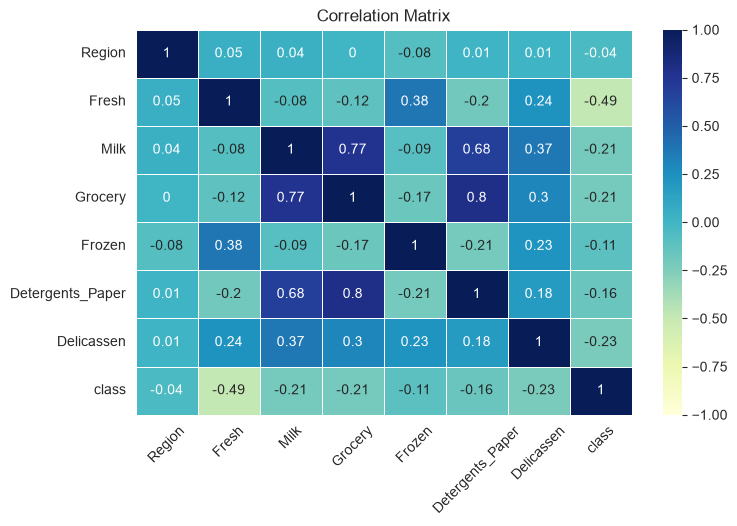

In [8]:
corr = od_df.corr(method="spearman").round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)

plt.show()

#### Target `class`

In [9]:
od_df["class"].value_counts(normalize=True).sort_values().mul(100).round(2).reset_index()

,class,proportion
0,1,19.77
1,3,39.32
2,2,40.91


#### Features

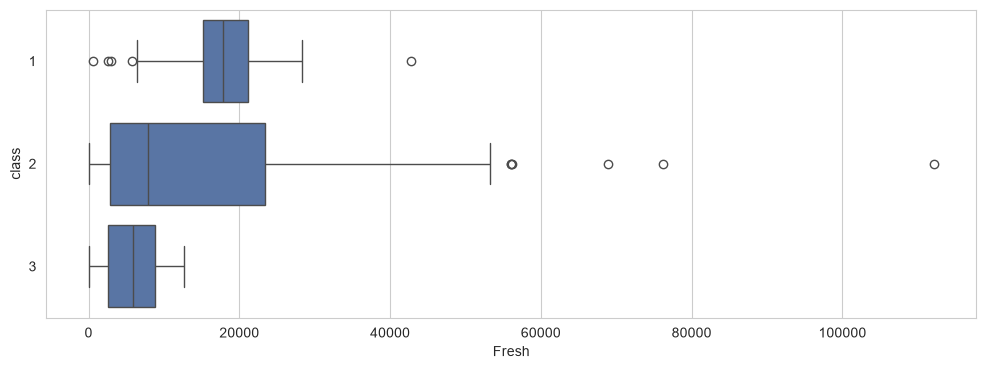

In [10]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Fresh", y="class", orient="h")
plt.show()

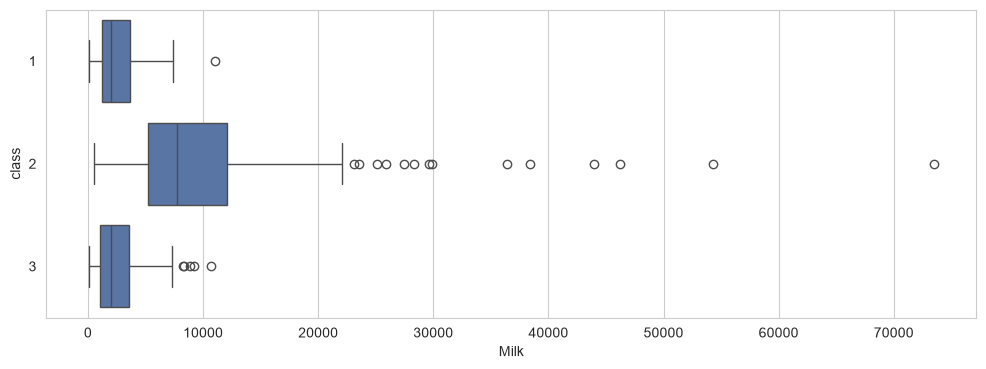

In [11]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Milk", y="class", orient="h")
plt.show()

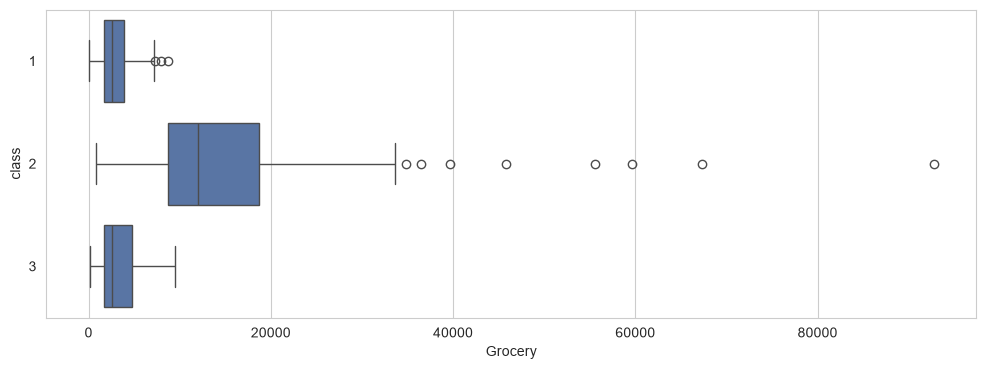

In [12]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Grocery", y="class", orient="h")
plt.show()

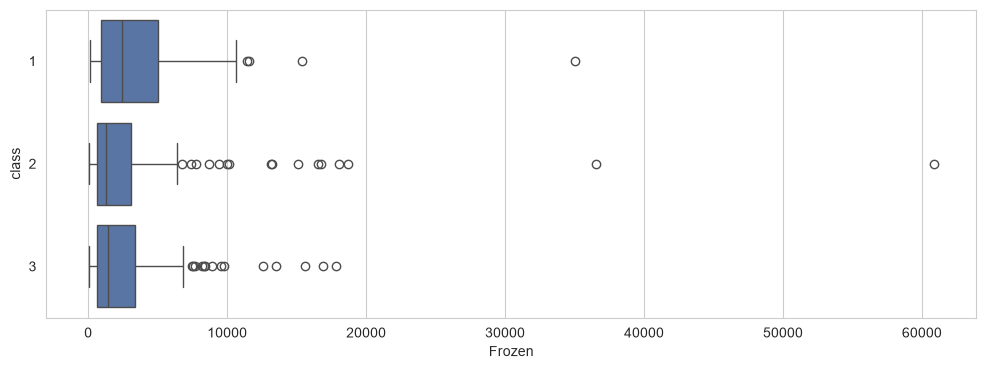

In [13]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Frozen", y="class", orient="h")
plt.show()

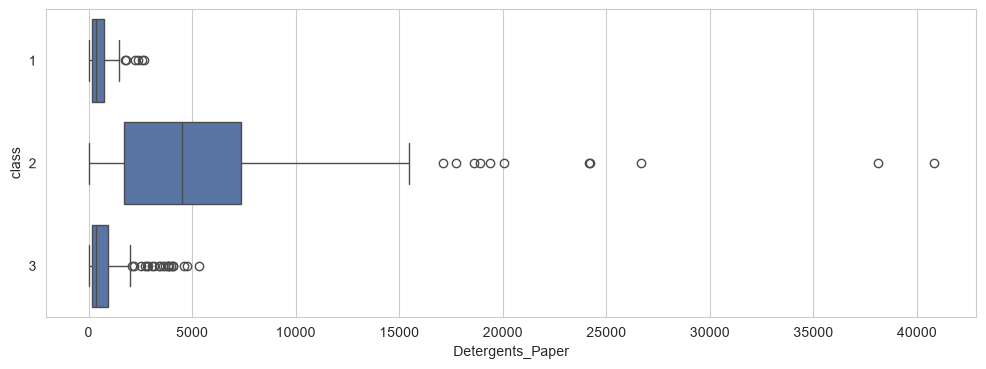

In [14]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Detergents_Paper", y="class", orient="h")
plt.show()

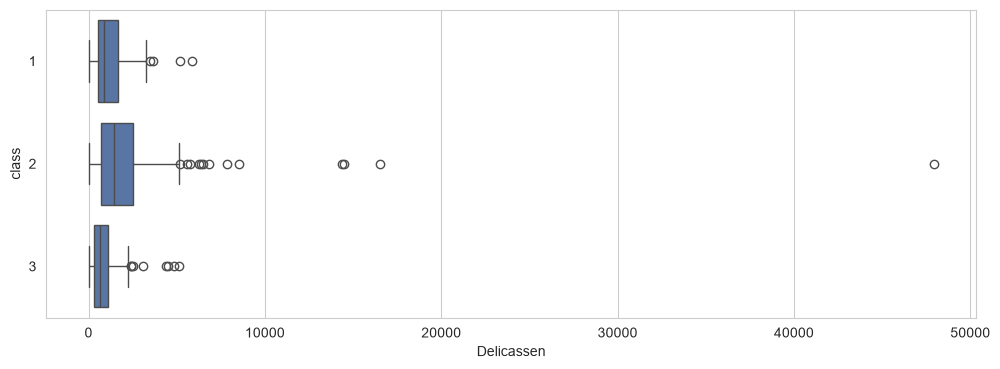

In [15]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Delicassen", y="class", orient="h")
plt.show()

#### Detect Outliers

In [16]:
print("Number of rows outside of IQR for each feature:\n")

for _, f_name in enumerate(od_df.select_dtypes(include="number").columns):
    _, out_row_count, out_per = detect_outliers(od_df, f_name)
    print(f"Feature `{f_name}`: {out_row_count} rows ({out_per}% of data)")

Number of rows outside of IQR for each feature:

Feature `Fresh`: 20 rows (4.55% of data)
Feature `Milk`: 28 rows (6.36% of data)
Feature `Grocery`: 24 rows (5.45% of data)
Feature `Frozen`: 43 rows (9.77% of data)
Feature `Detergents_Paper`: 30 rows (6.82% of data)
Feature `Delicassen`: 27 rows (6.14% of data)


#### Delete Outliers

In [17]:
od_wo_df = od_df.copy()  # Without outliers.

print("Deleting rows outside of IQR for each feature:\n")
for _, f_name in enumerate(od_wo_df.select_dtypes(include="number").columns):
    out_mask, _, _ = detect_outliers(od_wo_df, f_name)
    od_wo_df = od_wo_df[~out_mask]
    print(f"Feature `{f_name}`: {sum(out_mask)} rows deleted")

Deleting rows outside of IQR for each feature:

Feature `Fresh`: 20 rows deleted
Feature `Milk`: 24 rows deleted
Feature `Grocery`: 19 rows deleted
Feature `Frozen`: 37 rows deleted
Feature `Detergents_Paper`: 9 rows deleted
Feature `Delicassen`: 13 rows deleted


In [18]:
rc_bfr, _ = od_df.shape
rc_aft, _ = od_wo_df.shape
lc = rc_bfr - rc_aft
lp = lc / rc_bfr * 100
print(f"{lc} out of {rc_bfr} i.e., {lp:.2f} of rows were deleted and deleted as outliers.")

122 out of 440 i.e., 27.73 of rows were deleted and deleted as outliers.


#### Correlation Matrix

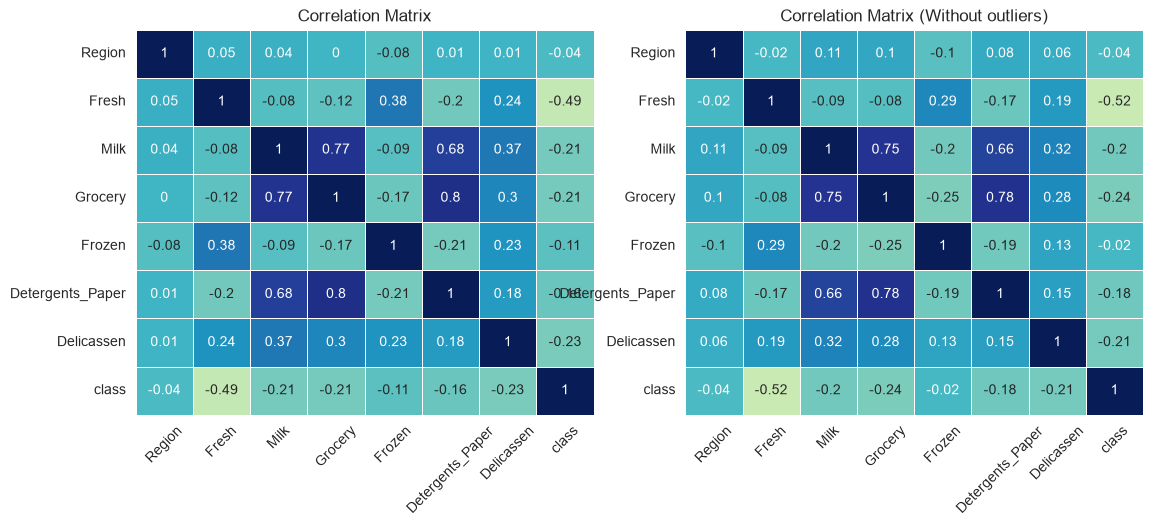

In [19]:
corr1 = od_df.corr(method="spearman").round(2)
corr2 = od_wo_df.corr(method="spearman").round(2)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.title("Correlation Matrix")
sns.heatmap(
    corr1, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True, cbar=False
)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.title("Correlation Matrix (Without outliers)")
sns.heatmap(
    corr2, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True, cbar=False
)
plt.xticks(rotation=45)

plt.show()

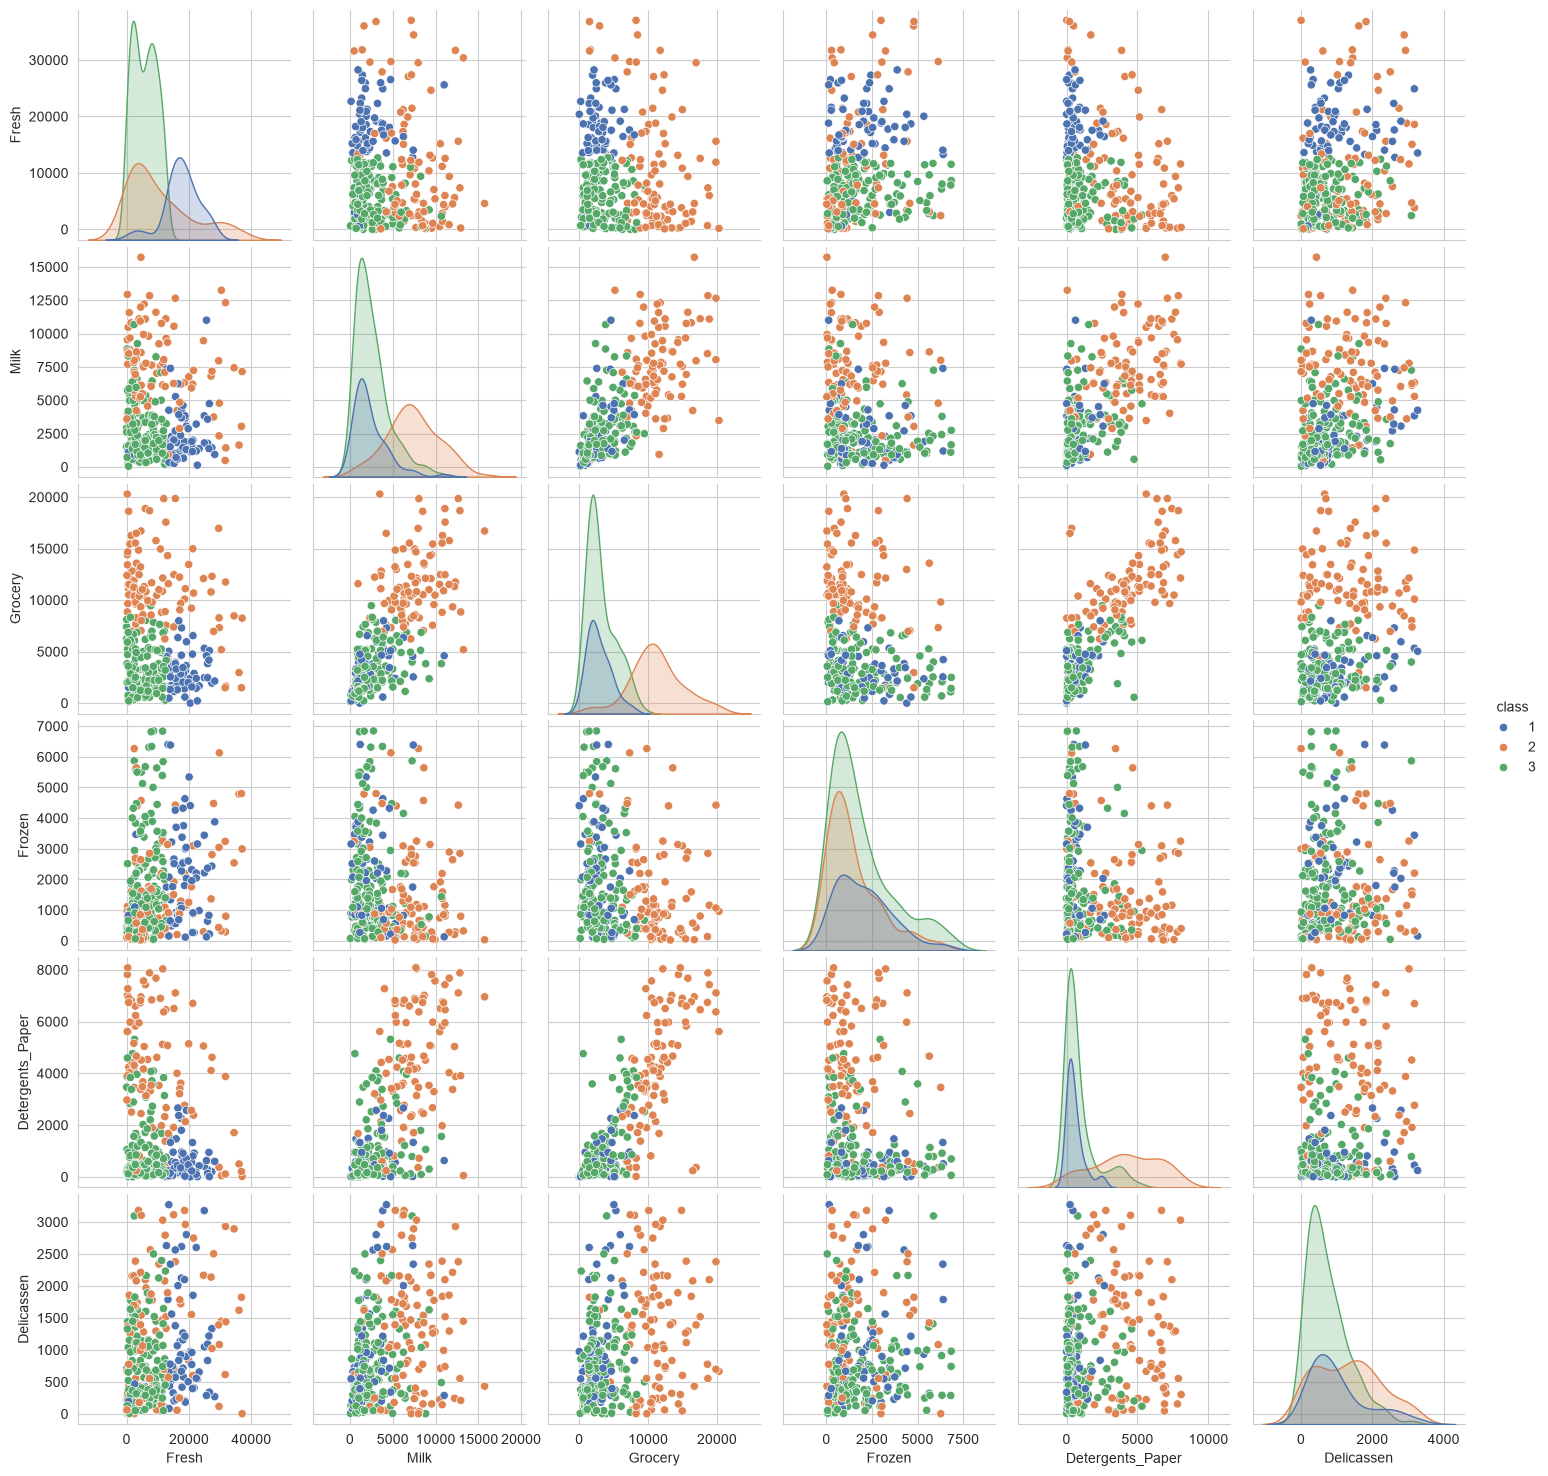

In [20]:
sns.pairplot(data=od_wo_df, hue="class")
plt.show()

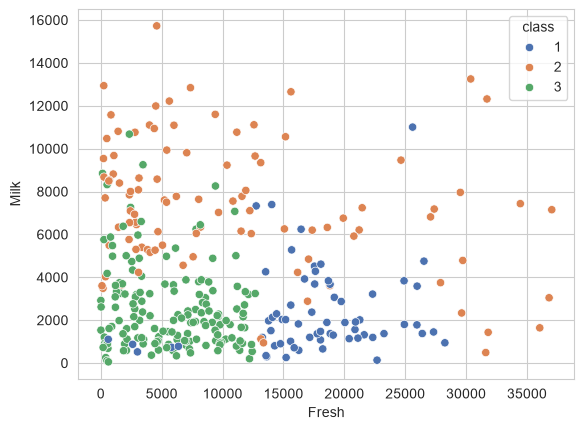

In [21]:
sns.scatterplot(data=od_wo_df, x="Fresh", y="Milk", hue="class")
# plt.savefig("images/data_points.png")
plt.show()

#### PCA on full Dataset

In [22]:
pc_df1 = pca(od_df, "class")

Reducing 7 dimensional data into 2 dimensions.


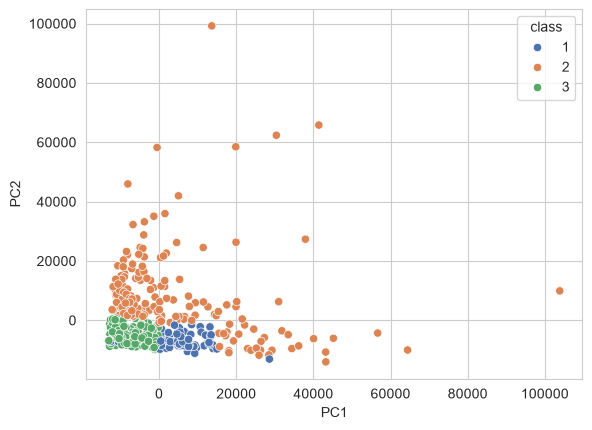

In [23]:
sns.scatterplot(data=pc_df1, x="PC1", y="PC2", hue="class")
plt.yticks(rotation=0)
plt.show()

#### PCA on Dataset without outliers

In [24]:
pc_df2 = pca(od_wo_df, "class")

Reducing 7 dimensional data into 2 dimensions.


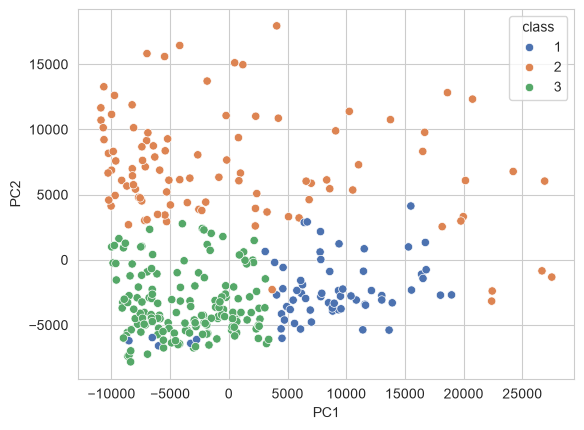

In [25]:
sns.scatterplot(data=pc_df2, x="PC1", y="PC2", hue="class")
plt.yticks(rotation=0)
plt.show()

### 3 Training Setup

#### Train test split

In [26]:
od_wo_df.columns

Index(['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen', 'class'], dtype='str')

In [27]:
X = od_wo_df[od_wo_df.columns.difference(["class"])]
y = od_wo_df["class"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((254, 7), (64, 7), (254,), (64,))

In [29]:
y_train.value_counts(normalize=True).mul(100).round(2)

class
3    48.82
2    30.71
1    20.47
Name: proportion, dtype: float64

In [30]:
y_test.value_counts(normalize=True).mul(100).round(2)

class
3    48.44
2    31.25
1    20.31
Name: proportion, dtype: float64

### 4 Feature Scaling

#### Scaling features using Standard Scalar

In [31]:
sd_sclr = StandardScaler()
X_train_scld = sd_sclr.fit_transform(X_train)

print("Sample rows to verify scaling:")
X_train_scld[:3]

Sample rows to verify scaling:


array([[-0.91584609,  0.1517121 , -0.27965597, -0.88393865, -0.07362546, -0.65286102, -0.67549836],
       [ 0.32938099, -0.79414551,  0.99950342,  0.4525631 , -0.78781038, -0.90552682,  0.5954393 ],
       [-0.83832701, -0.46286907, -0.8351899 ,  0.22939607, -0.14517646,  0.60675686,  0.5954393 ]])

### 5 Training

#### Base Model

In [32]:
model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(X_train_scld, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### Training Accuracy

In [33]:
model1.score(X_train_scld, y_train)

0.9212598425196851

### 6 Model Evaluation

In [34]:
X_test_scld = sd_sclr.transform(X_test)
print("Sample rows to verify scaling:")
X_test_scld[:3]

Sample rows to verify scaling:


array([[-1.15086424, -0.82310957, -1.15864987, -0.66077161, -1.09477298, -1.16097597,  0.5954393 ],
       [-0.72512455, -0.76291863, -0.53399533, -0.80267334, -0.73238045, -0.78769858,  0.5954393 ],
       [-0.47780178, -0.74255328,  0.64876222,  0.52132606, -0.3880965 , -0.61358494,  0.5954393 ]])

#### Testing Accuracy

In [35]:
model1.score(X_test_scld, y_test)

0.828125